In [1]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install xgboost
!pip install tensorflow
!pip install streamlit
!pip install speechrecognition
!pip install pyttsx3
!pip install google-generativeai
!pip install opencv-python

  Using cached protobuf-5.29.6-cp310-abi3-win_amd64.whl.metadata (592 bytes)
Using cached protobuf-5.29.6-cp310-abi3-win_amd64.whl (435 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.31.1
    Uninstalling protobuf-6.31.1:
      Successfully uninstalled protobuf-6.31.1


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.21.0 requires protobuf<8.0.0,>=6.31.1, but you have protobuf 5.29.6 which is incompatible.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [4]:
cols = ['unit_nr','time_cycles']

cols += [f'op_setting_{i}' for i in range(1,4)]

cols += [f'sensor_{i}' for i in range(1,22)]

train = pd.read_csv(
    r"C:\Users\Archana MP\Downloads\GROUP 2 AEROSPACE\Project Files\Dataset NASA FD001\train_FD001.txt",
    sep=r"\s+",
    header=None
)

train = train.iloc[:,:26]
train.columns = cols

train.head()

,unit_nr,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
print("Rows :", train.shape[0])
print("Columns :", train.shape[1])

train.head()

Rows : 20631
Columns : 26


,unit_nr,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [6]:
print(train.isnull().sum())

unit_nr         0
time_cycles     0
op_setting_1    0
op_setting_2    0
op_setting_3    0
sensor_1        0
sensor_2        0
sensor_3        0
sensor_4        0
sensor_5        0
sensor_6        0
sensor_7        0
sensor_8        0
sensor_9        0
sensor_10       0
sensor_11       0
sensor_12       0
sensor_13       0
sensor_14       0
sensor_15       0
sensor_16       0
sensor_17       0
sensor_18       0
sensor_19       0
sensor_20       0
sensor_21       0
dtype: int64


In [7]:
rul = train.groupby('unit_nr')['time_cycles'].max().reset_index()

rul.columns = ['unit_nr','max_cycle']

train = train.merge(rul,on='unit_nr')

train['RUL'] = train['max_cycle'] - train['time_cycles']

train.drop('max_cycle',axis=1,inplace=True)

train.head()

,unit_nr,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [8]:
train[['unit_nr','time_cycles','RUL']].head(20)

,unit_nr,time_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   unit_nr       20631 non-null  int64  
 1   time_cycles   20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   sensor_1      20631 non-null  float64
 6   sensor_2      20631 non-null  float64
 7   sensor_3      20631 non-null  float64
 8   sensor_4      20631 non-null  float64
 9   sensor_5      20631 non-null  float64
 10  sensor_6      20631 non-null  float64
 11  sensor_7      20631 non-null  float64
 12  sensor_8      20631 non-null  float64
 13  sensor_9      20631 non-null  float64
 14  sensor_10     20631 non-null  float64
 15  sensor_11     20631 non-null  float64
 16  sensor_12     20631 non-null  float64
 17  sensor_13     20631 non-null  float64
 18  sensor_14     20631 non-nu

In [10]:
train.describe()

,unit_nr,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,21.609803,553.367711,2388.096652,9065.242941,1.300000e+00,47.541168,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705,107.807862
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,0.001389,0.885092,0.070985,22.082880,4.660829e-13,0.267087,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251,68.880990
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,21.600000,549.850000,2387.900000,9021.730000,1.300000e+00,46.850000,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200,0.000000
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,21.610000,552.810000,2388.050000,9053.100000,1.300000e+00,47.350000,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800,51.000000
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,21.610000,553.440000,2388.090000,9060.660000,1.300000e+00,47.510000,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900,103.000000
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,21.610000,554.010000,2388.140000,9069.420000,1.300000e+00,47.700000,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800,155.000000
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,21.610000,556.060000,2388.560000,9244.590000,1.300000e+00,48.530000,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400,361.000000


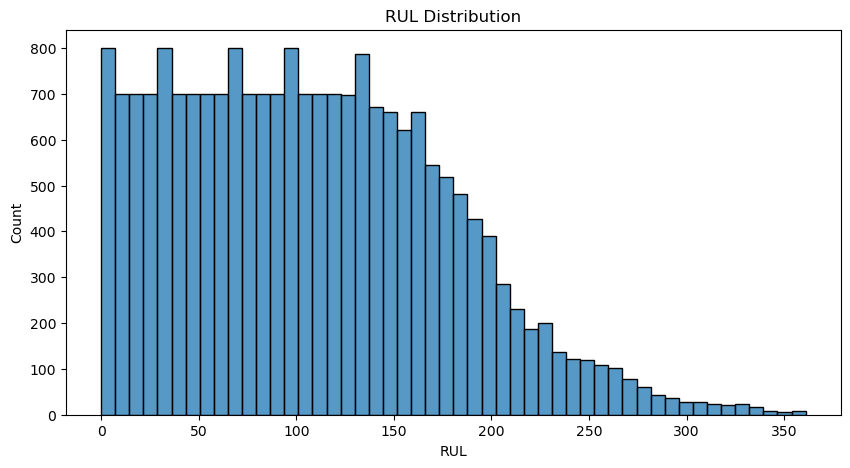

In [11]:
plt.figure(figsize=(10,5))
sns.histplot(train['RUL'], bins=50)
plt.title("RUL Distribution")
plt.show()

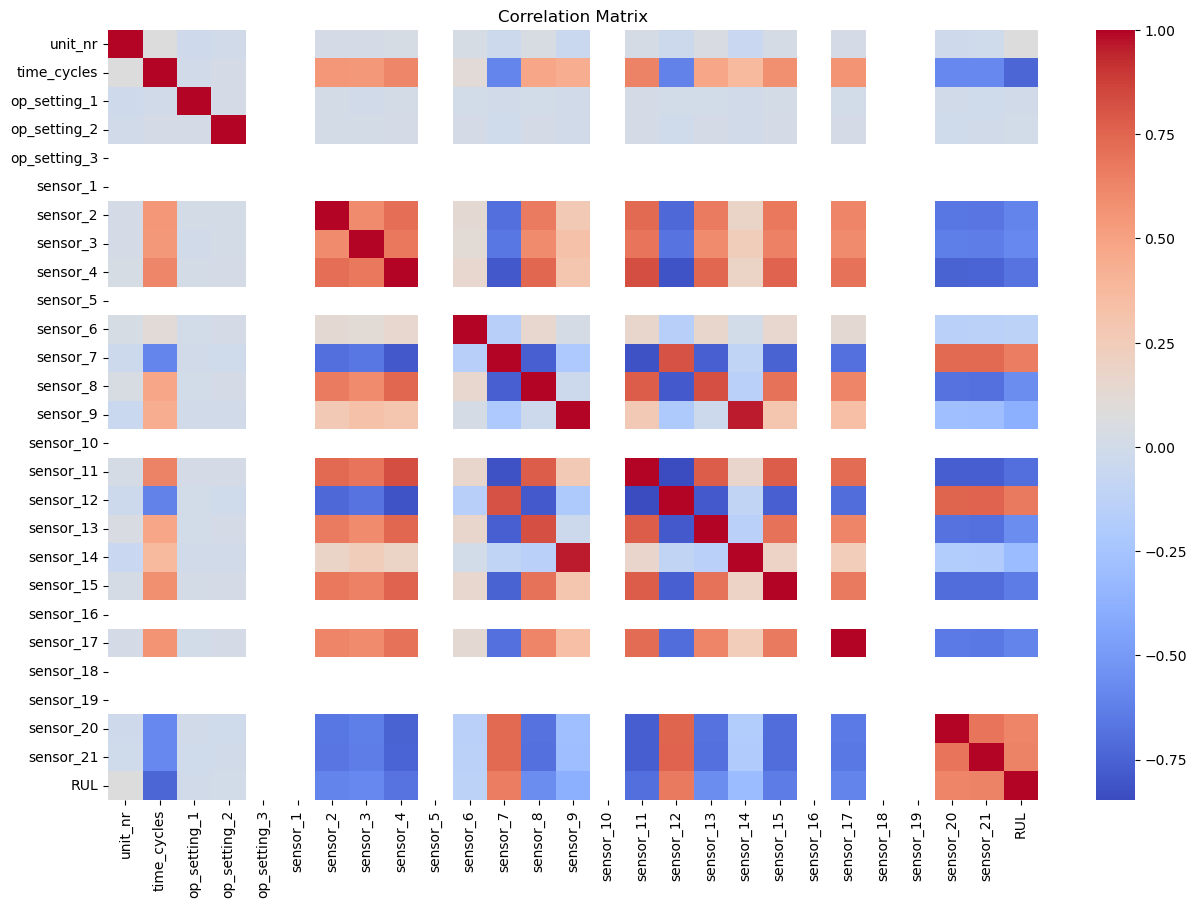

In [12]:
plt.figure(figsize=(15,10))

sns.heatmap(
    train.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [13]:
drop_cols = [
    'sensor_1',
    'sensor_5',
    'sensor_10',
    'sensor_16',
    'sensor_18',
    'sensor_19'
]

train.drop(columns=drop_cols,
           inplace=True)

train.shape

(20631, 21)

In [14]:
X = train.drop(
    ['RUL'],
    axis=1
)

y = train['RUL']

print(X.shape)
print(y.shape)

(20631, 20)
(20631,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)

(16504, 20)
(4127, 20)


In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

print(X_train_scaled.shape)

(16504, 20)


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import pandas as pd

In [18]:
models = {

    "Linear Regression":
    LinearRegression(),

    "Decision Tree":
    DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest":
    RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting":
    GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost":
    XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )
}

In [19]:
results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_val_scaled)

    mae = mean_absolute_error(
        y_val,
        pred
    )

    rmse = mean_squared_error(
        y_val,
        pred
    ) ** 0.5

    r2 = r2_score(
        y_val,
        pred
    )

    results.append(
        [name, mae, rmse, r2]
    )

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,30.415293,39.228015,0.663185
1,Decision Tree,13.185365,24.353009,0.870191
2,Random Forest,11.041437,16.160265,0.942840
3,Gradient Boosting,17.704022,23.815121,0.875862
4,XGBoost,8.925502,12.023411,0.968359


In [20]:
results_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
4,XGBoost,8.925502,12.023411,0.968359
2,Random Forest,11.041437,16.160265,0.942840
3,Gradient Boosting,17.704022,23.815121,0.875862
1,Decision Tree,13.185365,24.353009,0.870191
0,Linear Regression,30.415293,39.228015,0.663185


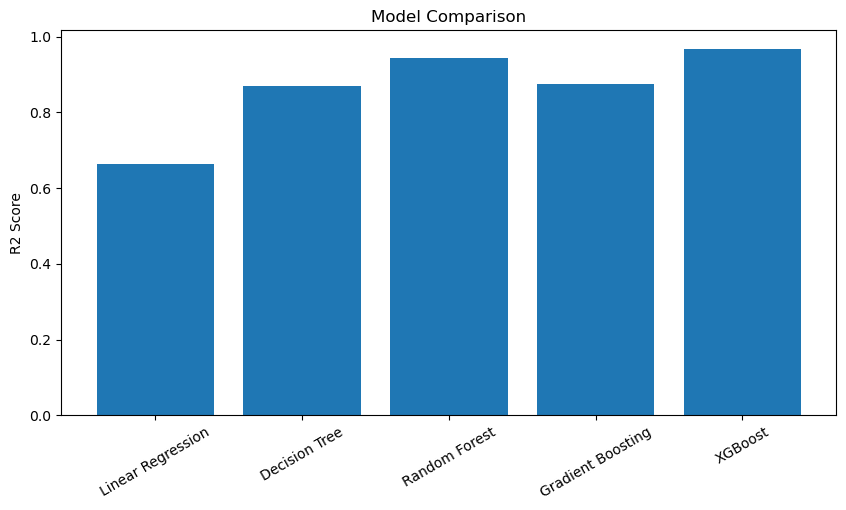

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    results_df["Model"],
    results_df["R2 Score"]
)

plt.xticks(rotation=30)

plt.title(
    "Model Comparison"
)

plt.ylabel("R2 Score")

plt.show()

In [22]:
best_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

best_model.fit(
    X_train_scaled,
    y_train
)

print("Best Model Trained")

Best Model Trained


In [23]:
import joblib

joblib.dump(
    best_model,
    "best_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Saved Successfully")

Saved Successfully


In [24]:
sample = X_val_scaled[0:1]

prediction = best_model.predict(
    sample
)

print(
    "Predicted RUL:",
    prediction[0]
)

Predicted RUL: 139.101


In [25]:
pip install protobuf==6.31.1 --no-cache-dir

  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.31.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.31.1 which is incompatible.


In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

import numpy as np

In [27]:
X_train_lstm = np.reshape(
    X_train_scaled,
    (X_train_scaled.shape[0],
     X_train_scaled.shape[1],
     1)
)

X_val_lstm = np.reshape(
    X_val_scaled,
    (X_val_scaled.shape[0],
     X_val_scaled.shape[1],
     1)
)

print(X_train_lstm.shape)
print(X_val_lstm.shape)

(16504, 20, 1)
(4127, 20, 1)


In [28]:
model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(
            X_train_lstm.shape[1],
            1
        )
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    LSTM(32)
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(1)
)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

c:\Users\Archana MP\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(
    X_train_lstm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_data=(
        X_val_lstm,
        y_val
    )
)

Epoch 1/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 14071.0020 - mae: 97.0419 - val_loss: 13089.3125 - val_mae: 93.6161
Epoch 2/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 12353.5820 - mae: 89.1803 - val_loss: 11639.1504 - val_mae: 86.9151
Epoch 3/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 11027.0479 - mae: 83.1667 - val_loss: 10397.8125 - val_mae: 81.2327
Epoch 4/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 9896.3740 - mae: 78.0698 - val_loss: 9332.4600 - val_mae: 76.3818
Epoch 5/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 8941.2480 - mae: 73.8300 - val_loss: 8418.3652 - val_mae: 72.2327
Epoch 6/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 8113.4214 - mae: 70.1491 - val_loss: 7641.4858 - val_mae: 68.7384
Epoch 7/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 7420.5098 - mae: 67.1345 - val_loss: 6983.8257 - val_mae: 65.8207
Epoch 8/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 6844.8853 - mae: 64.6845 - val_loss: 6435.47

In [30]:
lstm_pred = model.predict(
    X_val_lstm
)

lstm_pred[:5]

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


array([[104.89907],
       [104.89907],
       [104.89907],
       [104.89907],
       [104.89907]], dtype=float32)

In [31]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(
    y_val,
    lstm_pred
)

r2 = r2_score(
    y_val,
    lstm_pred
)

print("MAE:", mae)
print("R2:", r2)

MAE: 55.605220794677734
R2: -0.003331303596496582


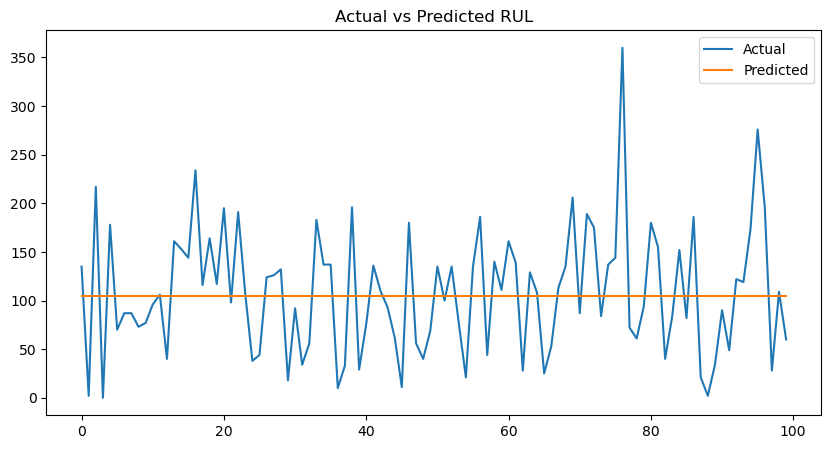

In [32]:
plt.figure(figsize=(10,5))

plt.plot(
    y_val.values[:100],
    label='Actual'
)

plt.plot(
    lstm_pred[:100],
    label='Predicted'
)

plt.legend()

plt.title(
    "Actual vs Predicted RUL"
)

plt.show()

In [33]:
model.save(
    "lstm_rul_model.h5"
)

print(
    "LSTM Model Saved"
)

LSTM Model Saved


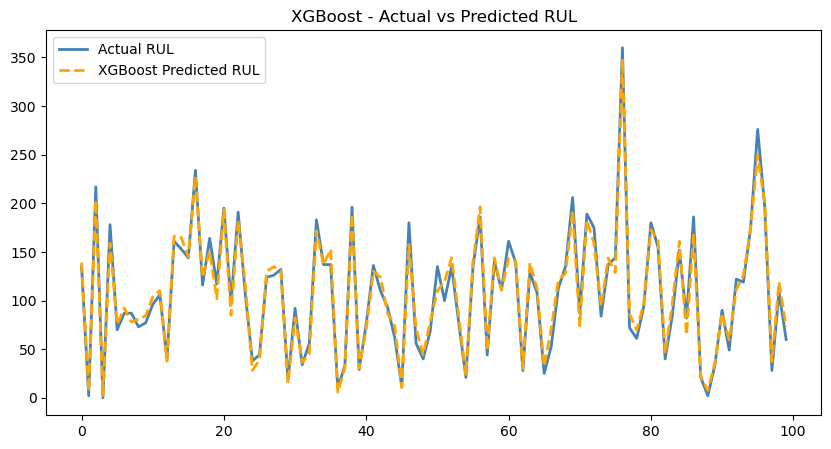

In [34]:
pred = best_model.predict(X_val_scaled)
plt.figure(figsize=(10, 5))
plt.plot(y_val.values[:100], label='Actual RUL', color='steelblue', linewidth=2)
plt.plot(pred[:100], label='XGBoost Predicted RUL', color='orange', linewidth=2, linestyle='--')
plt.legend()
plt.title("XGBoost - Actual vs Predicted RUL")
plt.show()

In [35]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

pred = best_model.predict(X_val_scaled)

mae = mean_absolute_error(y_val, pred)

rmse = np.sqrt(
    mean_squared_error(
        y_val,
        pred
    )
)

r2 = r2_score(
    y_val,
    pred
)

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 8.925501823425293
RMSE : 12.023411483686928
R2 Score : 0.9683587551116943


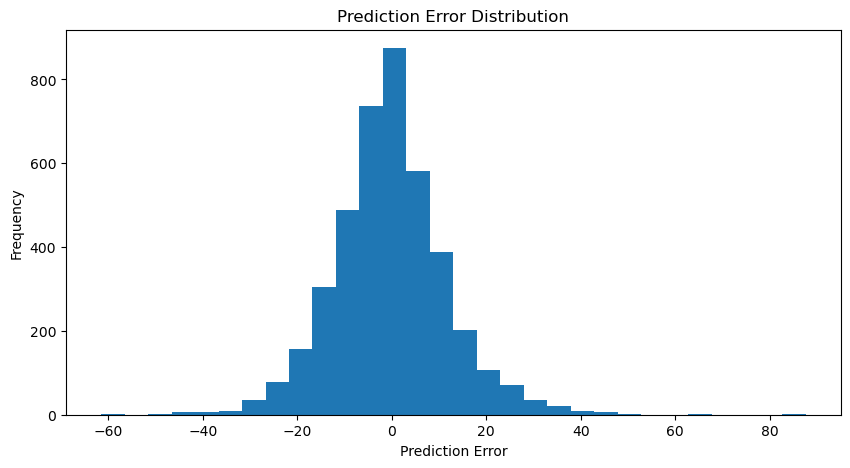

In [36]:
errors = y_val - pred

plt.figure(figsize=(10,5))

plt.hist(
    errors,
    bins=30
)

plt.title(
    "Prediction Error Distribution"
)

plt.xlabel(
    "Prediction Error"
)

plt.ylabel(
    "Frequency"
)

plt.show()

In [37]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(
    importance.head(10)
)

        Feature  Importance
1   time_cycles    0.355342
12    sensor_11    0.151806
7      sensor_4    0.115506
13    sensor_12    0.068783
0       unit_nr    0.057822
11     sensor_9    0.046020
9      sensor_7    0.041721
14    sensor_13    0.024963
16    sensor_15    0.022551
10     sensor_8    0.021557


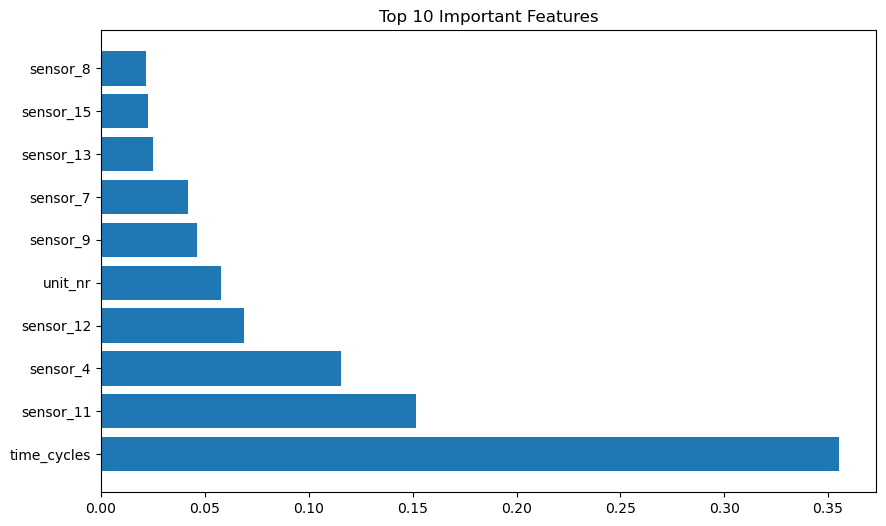

In [38]:
plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'][:10],
    importance['Importance'][:10]
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

In [39]:
import joblib

joblib.dump(
    best_model,
    "best_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Final XGBoost Model Saved")

Final XGBoost Model Saved


In [40]:
def maintenance_advice(rul):

    if rul > 100:
        return "Engine condition excellent"

    elif rul > 50:
        return "Routine inspection recommended"

    elif rul > 20:
        return "Maintenance required soon"

    else:
        return "Critical condition. Immediate maintenance required"

In [41]:
sample = X_val_scaled[0:1]

prediction = best_model.predict(
    sample
)[0]

print(
    "Predicted RUL:",
    round(prediction,2)
)

print(
    maintenance_advice(
        prediction
    )
)

Predicted RUL: 139.1
Engine condition excellent
